In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
train_df=pd.read_csv('IITG-train.csv')

In [3]:
train_df.head(3)

,id,title,Rating,maincateg,platform,price1,actprice1,Offer %,norating1,noreviews1,star_5f,star_4f,star_3f,star_2f,star_1f,fulfilled1
0,16695,Fashionable & Comfortable Bellies For Women (...,3.9,Women,Flipkart,698,999,30.13%,38.0,7.0,17.0,9.0,6.0,3,3,0
1,5120,Combo Pack of 4 Casual Shoes Sneakers For Men ...,3.8,Men,Flipkart,999,1999,50.03%,531.0,69.0,264.0,92.0,73.0,29,73,1
2,18391,Cilia Mode Leo Sneakers For Women (White),4.4,Women,Flipkart,2749,4999,45.01%,17.0,4.0,11.0,3.0,2.0,1,0,1


In [4]:
train_df.tail(3)

,id,title,Rating,maincateg,platform,price1,actprice1,Offer %,norating1,noreviews1,star_5f,star_4f,star_3f,star_2f,star_1f,fulfilled1
15727,6733,Women Navy Flats Sandal,3.7,Women,Flipkart,329,499,34.07%,NaN,18.0,NaN,NaN,20.0,10,15,1
15728,3889,Red Chief Men's Sneakers,3.9,Men,Amazon,2249,4499,50.01%,750.0,479.0,13.0,6.0,10.0,25,47,1
15729,13682,Slip On For Men (Brown),5.0,Men,Flipkart,1539,2799,45.02%,8.0,1.0,8.0,0.0,0.0,0,0,1


In [5]:
train_df.sample()

,id,title,Rating,maincateg,platform,price1,actprice1,Offer %,norating1,noreviews1,star_5f,star_4f,star_3f,star_2f,star_1f,fulfilled1
13825,797,RODEO-2 Running Shoes For Men (Black),4.2,Men,Flipkart,840,1149,8.01%,5386.0,899.0,3223.0,1270.0,1039.0,403,118,1


In [6]:
train_df.shape   # shape is a attribute not function

(15730, 16)

In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15730 entries, 0 to 15729
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          15730 non-null  int64  
 1   title       15730 non-null  object 
 2   Rating      15730 non-null  float64
 3   maincateg   15204 non-null  object 
 4   platform    15730 non-null  object 
 5   price1      15730 non-null  int64  
 6   actprice1   15730 non-null  int64  
 7   Offer %     15730 non-null  object 
 8   norating1   15052 non-null  float64
 9   noreviews1  15152 non-null  float64
 10  star_5f     15142 non-null  float64
 11  star_4f     15191 non-null  float64
 12  star_3f     15499 non-null  float64
 13  star_2f     15730 non-null  int64  
 14  star_1f     15730 non-null  int64  
 15  fulfilled1  15730 non-null  int64  
dtypes: float64(6), int64(6), object(4)
memory usage: 1.9+ MB


In [8]:
train_df.isnull().sum()

id              0
title           0
Rating          0
maincateg     526
platform        0
price1          0
actprice1       0
Offer %         0
norating1     678
noreviews1    578
star_5f       588
star_4f       539
star_3f       231
star_2f         0
star_1f         0
fulfilled1      0
dtype: int64

In [9]:
train_df.isnull().values.any()

True

<AxesSubplot:>

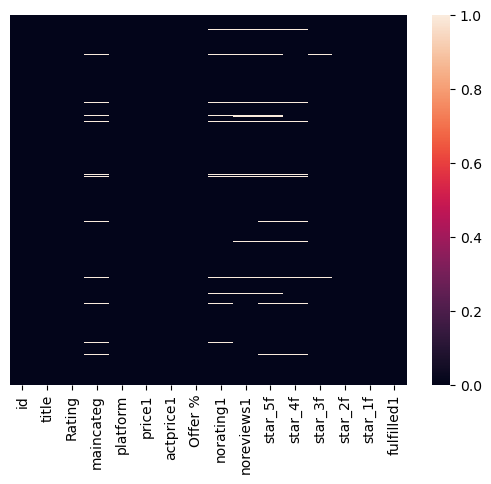

In [10]:
sns.heatmap(train_df.isnull(),yticklabels=False)

In [11]:
train_df.describe()

,id,Rating,price1,actprice1,norating1,noreviews1,star_5f,star_4f,star_3f,star_2f,star_1f,fulfilled1
count,15730.000000,15730.000000,15730.000000,15730.000000,15052.000000,15152.000000,15142.000000,15191.000000,15499.000000,15730.000000,15730.000000,15730.000000
mean,10479.541577,4.012873,688.070693,1369.286777,3057.660776,423.976307,1585.239466,655.923310,357.260662,155.085188,275.500572,0.601526
std,6080.166276,0.298440,649.409586,1240.900227,11846.965689,1768.230384,6177.476241,2855.735531,1402.246610,558.650254,958.589075,0.489600
min,3.000000,0.000000,69.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5212.000000,3.900000,349.000000,699.000000,63.000000,9.000000,30.000000,12.000000,7.000000,3.000000,6.000000,0.000000
50%,10458.500000,4.000000,474.000000,999.000000,308.000000,44.000000,150.000000,60.000000,34.000000,17.000000,30.000000,1.000000
75%,15766.750000,4.200000,699.000000,1299.000000,1526.000000,215.000000,788.000000,300.000000,172.000000,77.000000,140.000000,1.000000
max,20973.000000,5.000000,5998.000000,13499.000000,289973.000000,45448.000000,151193.000000,74037.000000,34978.000000,11705.000000,18060.000000,1.000000


In [12]:
# 1. rating --> try to remove rating below 3.9(25% data are below 3.9 rating) and check whether the accuracy is improving or not 
# 2. norating1 and noreviews1--> some products got higher no of rating counts and some got lesser no of rating count(data are skewed)
# 3. 5* to 1* --> data are skewed


In [13]:
train_df.duplicated().sum()

0

In [14]:
train_df.corr()

,id,Rating,price1,actprice1,norating1,noreviews1,star_5f,star_4f,star_3f,star_2f,star_1f,fulfilled1
id,1.000000,0.001126,0.004378,0.000651,0.008484,0.008225,0.008505,0.005041,0.006922,0.008491,0.009305,0.009788
Rating,0.001126,1.000000,0.291511,0.250502,0.017893,0.022477,0.027552,0.030310,0.000975,-0.023484,-0.031835,0.172736
price1,0.004378,0.291511,1.000000,0.889304,-0.045184,-0.040171,-0.040196,-0.031649,-0.056558,-0.071090,-0.070024,0.256335
actprice1,0.000651,0.250502,0.889304,1.000000,-0.064805,-0.062427,-0.061257,-0.055528,-0.071082,-0.080578,-0.079163,0.229107
norating1,0.008484,0.017893,-0.045184,-0.064805,1.000000,0.994984,0.990896,0.978589,0.988483,0.962727,0.942995,0.130749
noreviews1,0.008225,0.022477,-0.040171,-0.062427,0.994984,1.000000,0.986371,0.984529,0.983790,0.945473,0.919310,0.122997
star_5f,0.008505,0.027552,-0.040196,-0.061257,0.990896,0.986371,1.000000,0.975134,0.983479,0.956881,0.937830,0.131696
star_4f,0.005041,0.030310,-0.031649,-0.055528,0.978589,0.984529,0.975134,1.000000,0.973095,0.921937,0.888850,0.122629
star_3f,0.006922,0.000975,-0.056558,-0.071082,0.988483,0.983790,0.983479,0.973095,1.000000,0.977537,0.955915,0.124166
star_2f,0.008491,-0.023484,-0.071090,-0.080578,0.962727,0.945473,0.956881,0.921937,0.977537,1.000000,0.987995,0.127392


In [15]:
train_df.drop(['id'],axis=1,inplace=True)

In [16]:
train_df.sort_index()
#train_df_id = train_df[['id']] 

,title,Rating,maincateg,platform,price1,actprice1,Offer %,norating1,noreviews1,star_5f,star_4f,star_3f,star_2f,star_1f,fulfilled1
0,Fashionable & Comfortable Bellies For Women (...,3.9,Women,Flipkart,698,999,30.13%,38.0,7.0,17.0,9.0,6.0,3,3,0
1,Combo Pack of 4 Casual Shoes Sneakers For Men ...,3.8,Men,Flipkart,999,1999,50.03%,531.0,69.0,264.0,92.0,73.0,29,73,1
2,Cilia Mode Leo Sneakers For Women (White),4.4,Women,Flipkart,2749,4999,45.01%,17.0,4.0,11.0,3.0,2.0,1,0,1
3,Men Black Sports Sandal,4.2,Men,Flipkart,518,724,15.85%,46413.0,6229.0,1045.0,12416.0,5352.0,701,4595,1
4,Men Green Sports Sandal,3.9,Men,Flipkart,1379,2299,40.02%,77.0,3.0,35.0,21.0,7.0,7,7,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15725,Women Maroon Heels Sandal,4.3,Women,Flipkart,567,1199,52.71%,807.0,114.0,485.0,177.0,61.0,41,43,0
15726,Women Multicolor Flats Sandal,3.9,Women,Flipkart,499,998,50.00%,246.0,34.0,120.0,45.0,37.0,16,28,1
15727,Women Navy Flats Sandal,3.7,Women,Flipkart,329,499,34.07%,NaN,18.0,NaN,NaN,20.0,10,15,1
15728,Red Chief Men's Sneakers,3.9,Men,Amazon,2249,4499,50.01%,750.0,479.0,13.0,6.0,10.0,25,47,1


In [17]:
train_df['maincateg'] = ['Women' if 'omen' in x else 'Men' for x in train_df['title']] 
# fill maincateg col with the help of title

In [18]:
train_df.isnull().sum()

title           0
Rating          0
maincateg       0
platform        0
price1          0
actprice1       0
Offer %         0
norating1     678
noreviews1    578
star_5f       588
star_4f       539
star_3f       231
star_2f         0
star_1f         0
fulfilled1      0
dtype: int64

In [19]:
train_df.head(3)

,title,Rating,maincateg,platform,price1,actprice1,Offer %,norating1,noreviews1,star_5f,star_4f,star_3f,star_2f,star_1f,fulfilled1
0,Fashionable & Comfortable Bellies For Women (...,3.9,Women,Flipkart,698,999,30.13%,38.0,7.0,17.0,9.0,6.0,3,3,0
1,Combo Pack of 4 Casual Shoes Sneakers For Men ...,3.8,Men,Flipkart,999,1999,50.03%,531.0,69.0,264.0,92.0,73.0,29,73,1
2,Cilia Mode Leo Sneakers For Women (White),4.4,Women,Flipkart,2749,4999,45.01%,17.0,4.0,11.0,3.0,2.0,1,0,1


<AxesSubplot:>

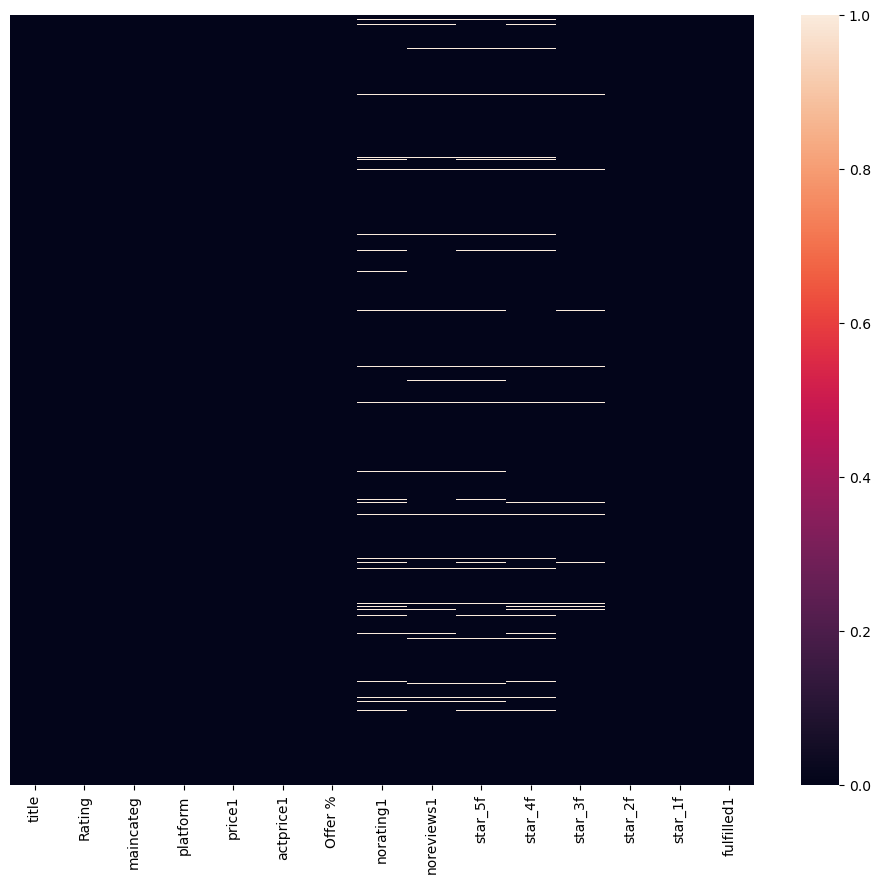

In [20]:

plt.figure(figsize=(12,10))   # 15 control width and 12 control length

sns.heatmap(train_df.isnull(),yticklabels=False)

In [21]:
train_df.shape

(15730, 15)

In [22]:

df1=train_df.dropna(thresh=12,axis=0)  

# keep those rows which have minimum 14 not-null value. 
# If any row have 13 not null value means (17-13=) 44 null value , then we discard those rows.

In [23]:
df1.describe()

,Rating,price1,actprice1,norating1,noreviews1,star_5f,star_4f,star_3f,star_2f,star_1f,fulfilled1
count,15379.000000,15379.000000,15379.000000,15041.000000,15128.000000,15120.000000,15157.000000,15315.000000,15379.000000,15379.000000,15379.000000
mean,4.013050,688.174459,1369.727681,3057.677415,424.405936,1585.230159,655.417035,356.521515,154.568503,274.812797,0.601535
std,0.298061,646.958988,1239.027107,11850.694503,1769.573912,6180.893430,2857.995606,1402.133804,559.941084,960.765403,0.489598
min,0.000000,69.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.900000,349.000000,699.000000,63.000000,9.000000,30.000000,12.000000,7.000000,3.000000,6.000000,0.000000
50%,4.000000,474.000000,999.000000,308.000000,44.000000,150.000000,60.000000,34.000000,17.000000,29.000000,1.000000
75%,4.200000,699.000000,1299.000000,1525.000000,215.000000,787.000000,299.000000,172.000000,77.000000,139.000000,1.000000
max,5.000000,5984.000000,13499.000000,289973.000000,45448.000000,151193.000000,74037.000000,34978.000000,11705.000000,18060.000000,1.000000


In [24]:
df1.shape

(15379, 15)

In [25]:
df1.isnull().sum()

title           0
Rating          0
maincateg       0
platform        0
price1          0
actprice1       0
Offer %         0
norating1     338
noreviews1    251
star_5f       259
star_4f       222
star_3f        64
star_2f         0
star_1f         0
fulfilled1      0
dtype: int64

In [26]:
df1[df1['noreviews1']==0]

,title,Rating,maincateg,platform,price1,actprice1,Offer %,norating1,noreviews1,star_5f,star_4f,star_3f,star_2f,star_1f,fulfilled1
27,Boots For Women (Brown),4.2,Women,Flipkart,599,999,40.04%,10.0,0.0,6.0,2.0,1.0,0,1,1
29,Women Black Flats Sandal,4.1,Women,Flipkart,831,1695,50.97%,14.0,0.0,7.0,4.0,1.0,1,1,1
40,Women's/Ladies/Female/Girls Lightweight Comfor...,4.4,Women,Flipkart,525,999,47.45%,5.0,0.0,3.0,1.0,1.0,0,0,0
110,Espadrilles For Men (White),2.3,Men,Flipkart,569,1599,64.42%,3.0,0.0,1.0,0.0,0.0,0,2,1
184,Women Beige Wedges Sandal,3.8,Women,Flipkart,449,549,18.21%,6.0,0.0,3.0,1.0,0.0,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15632,WMNS NIKE REVOLUTION 5 Running Shoes For Women...,4.7,Women,Flipkart,2217,3695,40.00%,3.0,0.0,2.0,1.0,0.0,0,0,1
15636,Casuals For Men (White),3.3,Men,Flipkart,349,999,65.07%,3.0,0.0,1.0,1.0,0.0,0,1,0
15649,"Jutis For Women (Brown, Grey)",4.3,Women,Flipkart,248,499,50.30%,11.0,0.0,6.0,2.0,1.0,0,1,0
15681,Jutis For Women (Pink),4.2,Women,Flipkart,219,499,56.11%,38.0,0.0,24.0,5.0,4.0,2,3,0


In [27]:
# masking

mask=df1['star_1f']+df1['star_2f']+df1['star_3f']+df1['star_4f']+df1['star_5f']==0  
# it means extract those rows which have all zero value in rating
print(df1[mask].shape)
df1[mask].head(3)
#df1[df1['star_2f']+df1['star_1f']+df1['star_3f']+df1['star_4f']+df1['star_5f']==0]

(45, 15)


,title,Rating,maincateg,platform,price1,actprice1,Offer %,norating1,noreviews1,star_5f,star_4f,star_3f,star_2f,star_1f,fulfilled1
1197,DOCTOR EXTRA SOFT Ortho Care Diabetic Orthopae...,4.0,Men,Flipkart,499,799,37.55%,3046.0,425.0,0.0,0.0,0.0,0,0,1
1413,Jutis For Men (Tan),4.3,Men,Flipkart,1530,1699,9.95%,22.0,5.0,0.0,0.0,0.0,0,0,0
1578,"Cosko Sports Shoes,Running Shoes,Walking Shoes...",4.1,Men,Flipkart,699,999,30.03%,122519.0,17774.0,0.0,0.0,0.0,0,0,1


In [28]:
df1[mask]=df1[mask].replace(0,np.nan)

C:\Users\BIPLAB\AppData\Local\Temp\ipykernel_12980\4165064671.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1[mask]=df1[mask].replace(0,np.nan)


In [29]:
df1.describe()

,Rating,price1,actprice1,norating1,noreviews1,star_5f,star_4f,star_3f,star_2f,star_1f,fulfilled1
count,15379.000000,15379.000000,15379.000000,15041.000000,15124.000000,15075.000000,15112.000000,15270.000000,15334.000000,15334.000000,15364.000000
mean,4.013050,688.174459,1369.727681,3057.677415,424.518183,1589.962189,657.368714,357.572168,155.022108,275.619277,0.602122
std,0.298061,646.958988,1239.027107,11850.694503,1769.794458,6189.504588,2862.023802,1404.064645,560.699446,962.058695,0.489476
min,0.000000,69.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.900000,349.000000,699.000000,63.000000,9.000000,30.000000,12.000000,7.000000,3.000000,6.000000,0.000000
50%,4.000000,474.000000,999.000000,308.000000,44.000000,152.000000,60.000000,34.000000,17.000000,30.000000,1.000000
75%,4.200000,699.000000,1299.000000,1525.000000,215.000000,789.000000,301.000000,172.000000,77.000000,140.000000,1.000000
max,5.000000,5984.000000,13499.000000,289973.000000,45448.000000,151193.000000,74037.000000,34978.000000,11705.000000,18060.000000,1.000000


In [30]:
df1.isnull().sum()

title           0
Rating          0
maincateg       0
platform        0
price1          0
actprice1       0
Offer %         0
norating1     338
noreviews1    255
star_5f       304
star_4f       267
star_3f       109
star_2f        45
star_1f        45
fulfilled1     15
dtype: int64

In [31]:
df1.head(3)

,title,Rating,maincateg,platform,price1,actprice1,Offer %,norating1,noreviews1,star_5f,star_4f,star_3f,star_2f,star_1f,fulfilled1
0,Fashionable & Comfortable Bellies For Women (...,3.9,Women,Flipkart,698,999,30.13%,38.0,7.0,17.0,9.0,6.0,3.0,3.0,0.0
1,Combo Pack of 4 Casual Shoes Sneakers For Men ...,3.8,Men,Flipkart,999,1999,50.03%,531.0,69.0,264.0,92.0,73.0,29.0,73.0,1.0
2,Cilia Mode Leo Sneakers For Women (White),4.4,Women,Flipkart,2749,4999,45.01%,17.0,4.0,11.0,3.0,2.0,1.0,0.0,1.0


In [32]:
df1.drop(['fulfilled1'],axis=1,inplace=True)

C:\Users\BIPLAB\AppData\Local\Temp\ipykernel_12980\1095107913.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1.drop(['fulfilled1'],axis=1,inplace=True)


In [33]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import KNNImputer
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer

In [34]:
mice_cols = ['Rating','actprice1','norating1','noreviews1','star_5f','star_4f','star_3f','star_2f','star_1f']
imputer = IterativeImputer()
df1[mice_cols]=imputer.fit_transform(df1[mice_cols])

C:\Users\BIPLAB\anaconda3\lib\site-packages\sklearn\impute\_iterative.py:699: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
C:\Users\BIPLAB\AppData\Local\Temp\ipykernel_12980\1827899590.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1[mice_cols]=imputer.fit_transform(df1[mice_cols])


In [35]:
df1.shape

(15379, 14)

In [36]:
df1.isnull().sum()

title         0
Rating        0
maincateg     0
platform      0
price1        0
actprice1     0
Offer %       0
norating1     0
noreviews1    0
star_5f       0
star_4f       0
star_3f       0
star_2f       0
star_1f       0
dtype: int64

In [37]:
df1.head(3)

,title,Rating,maincateg,platform,price1,actprice1,Offer %,norating1,noreviews1,star_5f,star_4f,star_3f,star_2f,star_1f
0,Fashionable & Comfortable Bellies For Women (...,3.9,Women,Flipkart,698,999.0,30.13%,38.0,7.0,17.0,9.0,6.0,3.0,3.0
1,Combo Pack of 4 Casual Shoes Sneakers For Men ...,3.8,Men,Flipkart,999,1999.0,50.03%,531.0,69.0,264.0,92.0,73.0,29.0,73.0
2,Cilia Mode Leo Sneakers For Women (White),4.4,Women,Flipkart,2749,4999.0,45.01%,17.0,4.0,11.0,3.0,2.0,1.0,0.0


In [38]:
df1.describe()

,Rating,price1,actprice1,norating1,noreviews1,star_5f,star_4f,star_3f,star_2f,star_1f
count,15379.000000,15379.000000,15379.000000,15379.000000,15379.000000,15379.000000,15379.000000,15379.000000,15379.000000,15379.000000
mean,4.013050,688.174459,1369.727681,3064.589605,426.653180,1606.686473,659.560976,360.091401,155.403886,276.298663
std,0.298061,646.958988,1239.027107,11985.681680,1764.880139,6308.094352,2857.705668,1431.856757,561.868560,964.158343
min,0.000000,69.000000,42.000000,1.000000,-28.861199,-33.648751,-86.389294,-14.122010,-3.074494,0.000000
25%,3.900000,349.000000,699.000000,65.000000,9.000000,31.000000,12.000000,7.000000,3.000000,6.000000
50%,4.000000,474.000000,999.000000,311.000000,44.000000,157.000000,61.000000,34.000000,17.000000,30.000000
75%,4.200000,699.000000,1299.000000,1515.500000,215.000000,789.000000,302.000000,172.000000,77.000000,140.000000
max,5.000000,5984.000000,13499.000000,290808.048306,45448.000000,151193.000000,74037.000000,34978.000000,11705.000000,18060.000000


In [39]:
df1.drop(columns=['title','Offer %'],axis=1,inplace=True)

C:\Users\BIPLAB\AppData\Local\Temp\ipykernel_12980\1933678435.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1.drop(columns=['title','Offer %'],axis=1,inplace=True)


In [40]:
df1

,Rating,maincateg,platform,price1,actprice1,norating1,noreviews1,star_5f,star_4f,star_3f,star_2f,star_1f
0,3.9,Women,Flipkart,698,999.0,38.000000,7.0,17.000000,9.00000,6.0,3.0,3.0
1,3.8,Men,Flipkart,999,1999.0,531.000000,69.0,264.000000,92.00000,73.0,29.0,73.0
2,4.4,Women,Flipkart,2749,4999.0,17.000000,4.0,11.000000,3.00000,2.0,1.0,0.0
3,4.2,Men,Flipkart,518,724.0,46413.000000,6229.0,1045.000000,12416.00000,5352.0,701.0,4595.0
4,3.9,Men,Flipkart,1379,2299.0,77.000000,3.0,35.000000,21.00000,7.0,7.0,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...
15725,4.3,Women,Flipkart,567,1199.0,807.000000,114.0,485.000000,177.00000,61.0,41.0,43.0
15726,3.9,Women,Flipkart,499,998.0,246.000000,34.0,120.000000,45.00000,37.0,16.0,28.0
15727,3.7,Women,Flipkart,329,499.0,202.673581,18.0,130.688779,37.46565,20.0,10.0,15.0
15728,3.9,Men,Amazon,2249,4499.0,750.000000,479.0,13.000000,6.00000,10.0,25.0,47.0


In [41]:
df1[df1['actprice1']<df1['price1']].shape

(39, 12)

In [42]:
df1[df1['actprice1']<df1['price1']]

,Rating,maincateg,platform,price1,actprice1,norating1,noreviews1,star_5f,star_4f,star_3f,star_2f,star_1f
725,3.8,Women,Flipkart,863,738.0,418.0,66.0,146.0,151.0,35.0,17.0,61.0
901,4.1,Women,Flipkart,1561,1541.0,366.0,35.0,196.0,73.0,16.0,19.0,28.0
1472,4.3,Women,Flipkart,508,472.0,126.0,19.0,110.0,17.0,7.0,8.0,6.0
1596,4.3,Women,Flipkart,853,799.0,19.0,2.0,8.0,6.0,2.0,1.0,1.0
1946,4.1,Men,Flipkart,329,328.0,2842.0,378.0,2118.0,630.0,446.0,192.0,240.0
2010,4.0,Men,Flipkart,461,457.0,40969.0,6923.0,12799.0,13733.0,5191.0,3026.0,5042.0
2139,4.7,Women,Amazon,525,431.0,4.0,2.0,2.0,1.0,1.0,42.0,86.0
2387,4.4,Women,Flipkart,554,418.0,129.0,20.0,56.0,43.0,11.0,4.0,3.0
2498,3.8,Men,Flipkart,370,302.0,741.0,81.0,73.0,67.0,57.0,98.0,216.0
4145,3.7,Women,Flipkart,564,538.0,125.0,20.0,20.0,26.0,33.0,8.0,21.0


In [43]:
df1[['price1','actprice1']] = df1[['actprice1','price1']].where(df1['actprice1']<df1['price1'], df1[['price1','actprice1']].values)

C:\Users\BIPLAB\AppData\Local\Temp\ipykernel_12980\873310573.py:1: FutureWarning: Downcasting integer-dtype results in .where is deprecated and will change in a future version. To retain the old behavior, explicitly cast the results to the desired dtype.
  df1[['price1','actprice1']] = df1[['actprice1','price1']].where(df1['actprice1']<df1['price1'], df1[['price1','actprice1']].values)
C:\Users\BIPLAB\AppData\Local\Temp\ipykernel_12980\873310573.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1[['price1','actprice1']] = df1[['actprice1','price1']].where(df1['actprice1']<df1['price1'], df1[['price1','actprice1']].values)


In [44]:
df1[df1['actprice1']<df1['price1']].shape

(0, 12)

In [45]:
df1['positive_feedback']=df1['star_5f']+df1['star_4f']
df1['negative_feedback']=df1['star_3f']+df1['star_2f']+df1['star_1f']

C:\Users\BIPLAB\AppData\Local\Temp\ipykernel_12980\272329121.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['positive_feedback']=df1['star_5f']+df1['star_4f']
C:\Users\BIPLAB\AppData\Local\Temp\ipykernel_12980\272329121.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['negative_feedback']=df1['star_3f']+df1['star_2f']+df1['star_1f']


In [46]:
df1[df1['negative_feedback']==0].shape

(257, 14)

In [47]:
df1[df1['negative_feedback']==0]

,Rating,maincateg,platform,price1,actprice1,norating1,noreviews1,star_5f,star_4f,star_3f,star_2f,star_1f,positive_feedback,negative_feedback
171,5.0,Men,Flipkart,449.0,749,3.0,1.0,3.0,0.0,0.0,0.0,0.0,3.0,0.0
222,4.7,Men,Flipkart,599.0,1199,3.0,0.0,2.0,1.0,0.0,0.0,0.0,3.0,0.0
265,4.5,Women,Flipkart,798.0,799,6.0,0.0,3.0,3.0,0.0,0.0,0.0,6.0,0.0
294,4.7,Women,Flipkart,4785.0,7995,3.0,1.0,2.0,1.0,0.0,0.0,0.0,3.0,0.0
301,4.8,Women,Flipkart,3574.0,6499,10.0,0.0,8.0,2.0,0.0,0.0,0.0,10.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15552,4.8,Women,Flipkart,569.0,1299,4.0,0.0,3.0,1.0,0.0,0.0,0.0,4.0,0.0
15591,4.7,Women,Flipkart,219.0,1299,3.0,1.0,2.0,1.0,0.0,0.0,0.0,3.0,0.0
15632,4.7,Women,Flipkart,2217.0,3695,3.0,0.0,2.0,1.0,0.0,0.0,0.0,3.0,0.0
15724,5.0,Men,Flipkart,649.0,2199,2.0,1.0,2.0,0.0,0.0,0.0,0.0,2.0,0.0


In [48]:
df1.shape

(15379, 14)

In [49]:
df1.drop(df1[df1['negative_feedback']==0].index, inplace = True)

C:\Users\BIPLAB\AppData\Local\Temp\ipykernel_12980\3475848140.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1.drop(df1[df1['negative_feedback']==0].index, inplace = True)


In [50]:
df1.shape

(15122, 14)

In [51]:
df1[df1['positive_feedback']==0].shape

(33, 14)

In [52]:
df1[df1['positive_feedback']==0]

,Rating,maincateg,platform,price1,actprice1,norating1,noreviews1,star_5f,star_4f,star_3f,star_2f,star_1f,positive_feedback,negative_feedback
23,4.7,Men,Amazon,1596.0,1607,8.0,4.0,0.0,0.0,0.0,30.0,70.0,0.0,100.0
92,4.7,Women,Amazon,599.0,599,4.0,2.0,0.0,0.0,0.0,30.0,70.0,0.0,100.0
272,4.4,Women,Amazon,949.0,949,17.0,10.0,0.0,0.0,9.0,43.0,48.0,0.0,100.0
300,3.8,Men,Amazon,348.0,348,4.0,3.0,0.0,0.0,0.0,30.0,70.0,0.0,100.0
509,4.3,Women,Amazon,449.0,449,5.0,2.0,0.0,0.0,23.0,23.0,54.0,0.0,100.0
560,4.7,Men,Amazon,399.0,399,18.0,10.0,0.0,0.0,0.0,29.0,71.0,0.0,100.0
662,3.4,Men,Amazon,499.0,599,11.0,9.0,0.0,0.0,30.0,13.0,57.0,0.0,100.0
1838,4.4,Men,Amazon,449.0,449,8.0,5.0,0.0,0.0,16.0,27.0,57.0,0.0,100.0
2397,4.7,Men,Amazon,399.0,399,18.0,10.0,0.0,0.0,0.0,29.0,71.0,0.0,100.0
3057,4.5,Men,Amazon,2446.0,2469,20.0,9.0,0.0,0.0,12.0,29.0,58.0,0.0,99.0


In [53]:
df1.drop(df1[df1['positive_feedback']==0].index, inplace = True)

C:\Users\BIPLAB\AppData\Local\Temp\ipykernel_12980\1345892405.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1.drop(df1[df1['positive_feedback']==0].index, inplace = True)


In [54]:
df1.shape

(15089, 14)

In [55]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 15089 entries, 0 to 15728
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Rating             15089 non-null  float64
 1   maincateg          15089 non-null  object 
 2   platform           15089 non-null  object 
 3   price1             15089 non-null  float64
 4   actprice1          15089 non-null  int64  
 5   norating1          15089 non-null  float64
 6   noreviews1         15089 non-null  float64
 7   star_5f            15089 non-null  float64
 8   star_4f            15089 non-null  float64
 9   star_3f            15089 non-null  float64
 10  star_2f            15089 non-null  float64
 11  star_1f            15089 non-null  float64
 12  positive_feedback  15089 non-null  float64
 13  negative_feedback  15089 non-null  float64
dtypes: float64(11), int64(1), object(2)
memory usage: 1.7+ MB


In [56]:
df1=df1.astype({'Rating':'int','price1':'int','norating1':'int','noreviews1':'int','star_5f':'int','star_4f':'int','star_3f':'int','star_2f':'int','star_1f':'int','positive_feedback':'int','negative_feedback':'int'})

In [57]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 15089 entries, 0 to 15728
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Rating             15089 non-null  int32 
 1   maincateg          15089 non-null  object
 2   platform           15089 non-null  object
 3   price1             15089 non-null  int32 
 4   actprice1          15089 non-null  int64 
 5   norating1          15089 non-null  int32 
 6   noreviews1         15089 non-null  int32 
 7   star_5f            15089 non-null  int32 
 8   star_4f            15089 non-null  int32 
 9   star_3f            15089 non-null  int32 
 10  star_2f            15089 non-null  int32 
 11  star_1f            15089 non-null  int32 
 12  positive_feedback  15089 non-null  int32 
 13  negative_feedback  15089 non-null  int32 
dtypes: int32(11), int64(1), object(2)
memory usage: 1.1+ MB


In [58]:
df1.head(3)

,Rating,maincateg,platform,price1,actprice1,norating1,noreviews1,star_5f,star_4f,star_3f,star_2f,star_1f,positive_feedback,negative_feedback
0,3,Women,Flipkart,698,999,38,7,17,9,6,3,3,26,12
1,3,Men,Flipkart,999,1999,531,69,264,92,73,29,73,356,175
2,4,Women,Flipkart,2749,4999,17,4,11,3,2,1,0,14,3


In [59]:
df1['maincateg'].replace({'Men':0,'Women':1},inplace=True)

In [60]:
df1['platform'].replace({'Amazon':0,'Flipkart':1},inplace=True)

In [61]:
df1.head(3)

,Rating,maincateg,platform,price1,actprice1,norating1,noreviews1,star_5f,star_4f,star_3f,star_2f,star_1f,positive_feedback,negative_feedback
0,3,1,1,698,999,38,7,17,9,6,3,3,26,12
1,3,0,1,999,1999,531,69,264,92,73,29,73,356,175
2,4,1,1,2749,4999,17,4,11,3,2,1,0,14,3


C:\Users\BIPLAB\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='price1', ylabel='Density'>

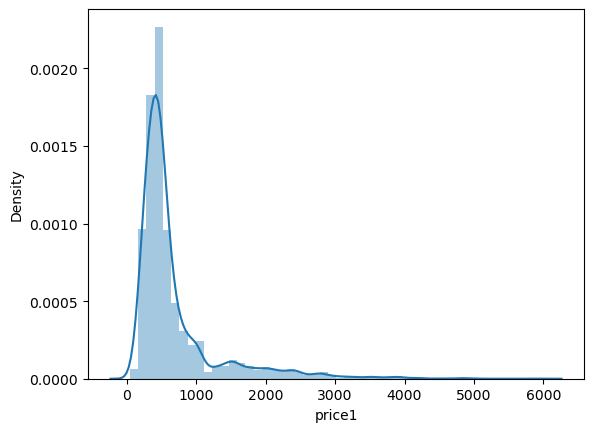

In [62]:
sns.distplot(df1['price1'])

C:\Users\BIPLAB\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='actprice1', ylabel='Density'>

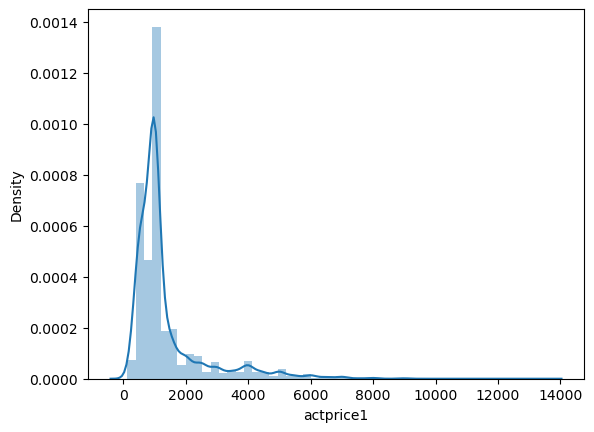

In [63]:
sns.distplot(df1['actprice1'])

C:\Users\BIPLAB\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='norating1', ylabel='Density'>

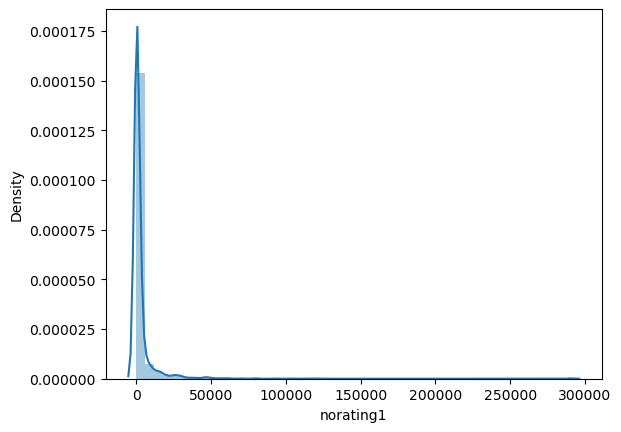

In [64]:
sns.distplot(df1['norating1'])

C:\Users\BIPLAB\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='noreviews1', ylabel='Density'>

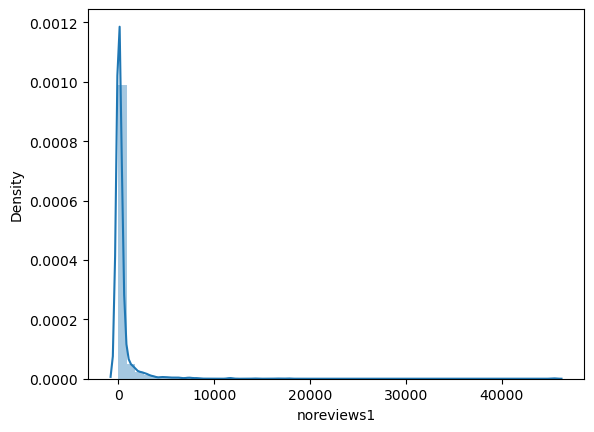

In [65]:
sns.distplot(df1['noreviews1'])

C:\Users\BIPLAB\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='star_5f', ylabel='Density'>

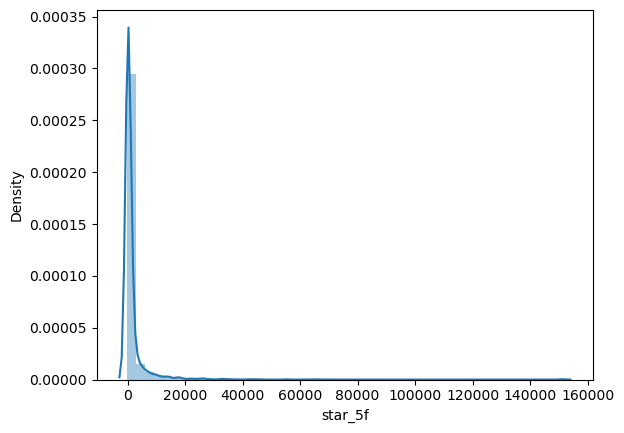

In [66]:
sns.distplot(df1['star_5f'])

C:\Users\BIPLAB\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='star_4f', ylabel='Density'>

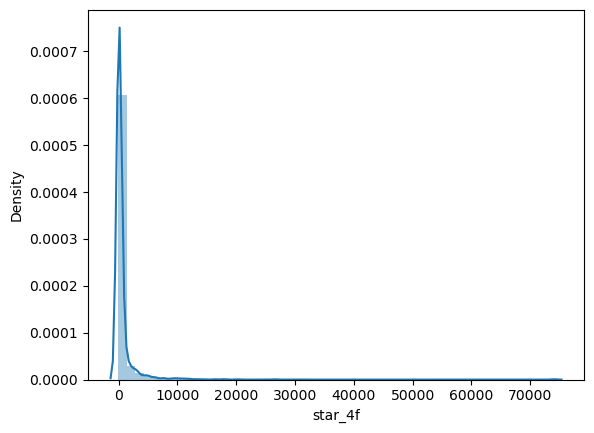

In [67]:
sns.distplot(df1['star_4f'])

C:\Users\BIPLAB\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='star_3f', ylabel='Density'>

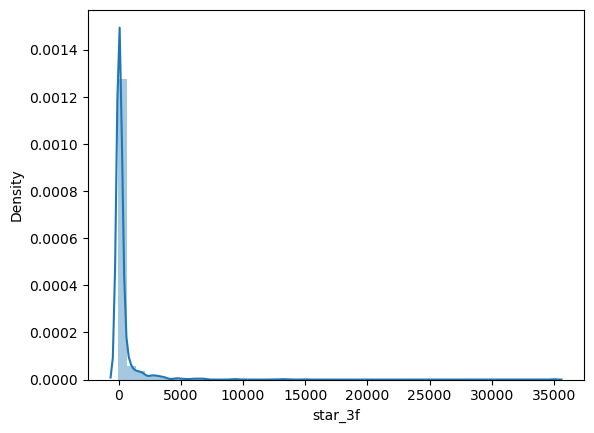

In [68]:
sns.distplot(df1['star_3f'])

C:\Users\BIPLAB\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='star_2f', ylabel='Density'>

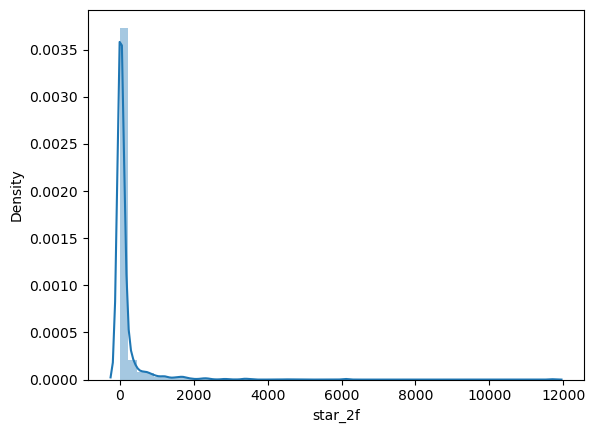

In [69]:
sns.distplot(df1['star_2f'])

C:\Users\BIPLAB\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='star_1f', ylabel='Density'>

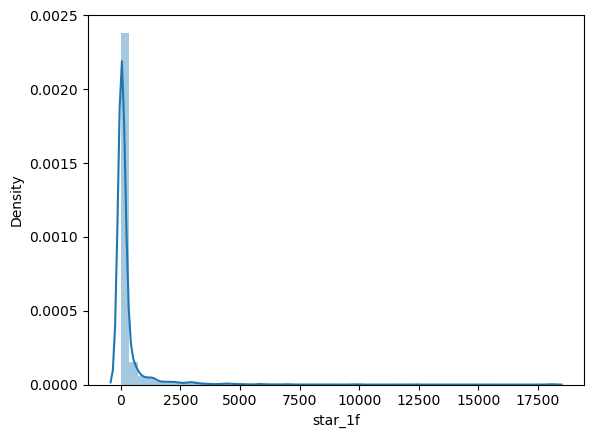

In [70]:
sns.distplot(df1['star_1f'])

C:\Users\BIPLAB\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='positive_feedback', ylabel='Density'>

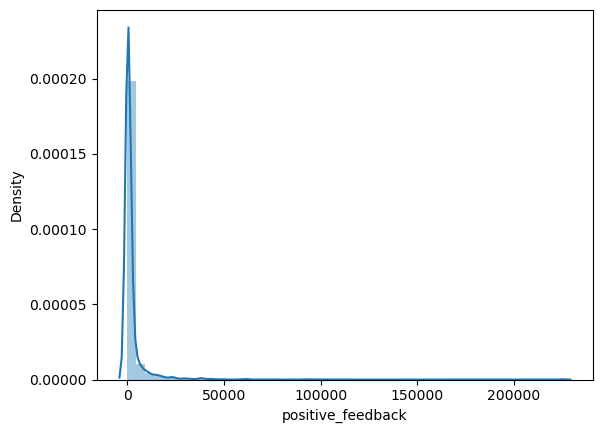

In [71]:
sns.distplot(df1['positive_feedback'])

C:\Users\BIPLAB\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='negative_feedback', ylabel='Density'>

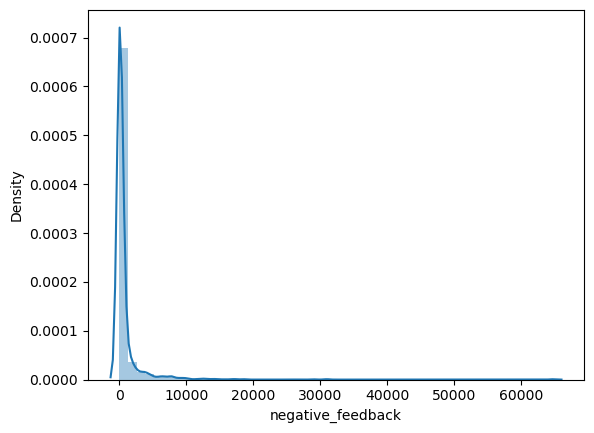

In [72]:
sns.distplot(df1['negative_feedback'])

C:\Users\BIPLAB\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='negative_feedback'>

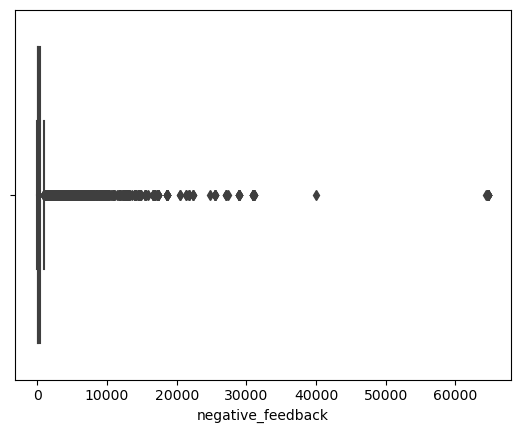

In [73]:
sns.boxplot(df1['negative_feedback'])

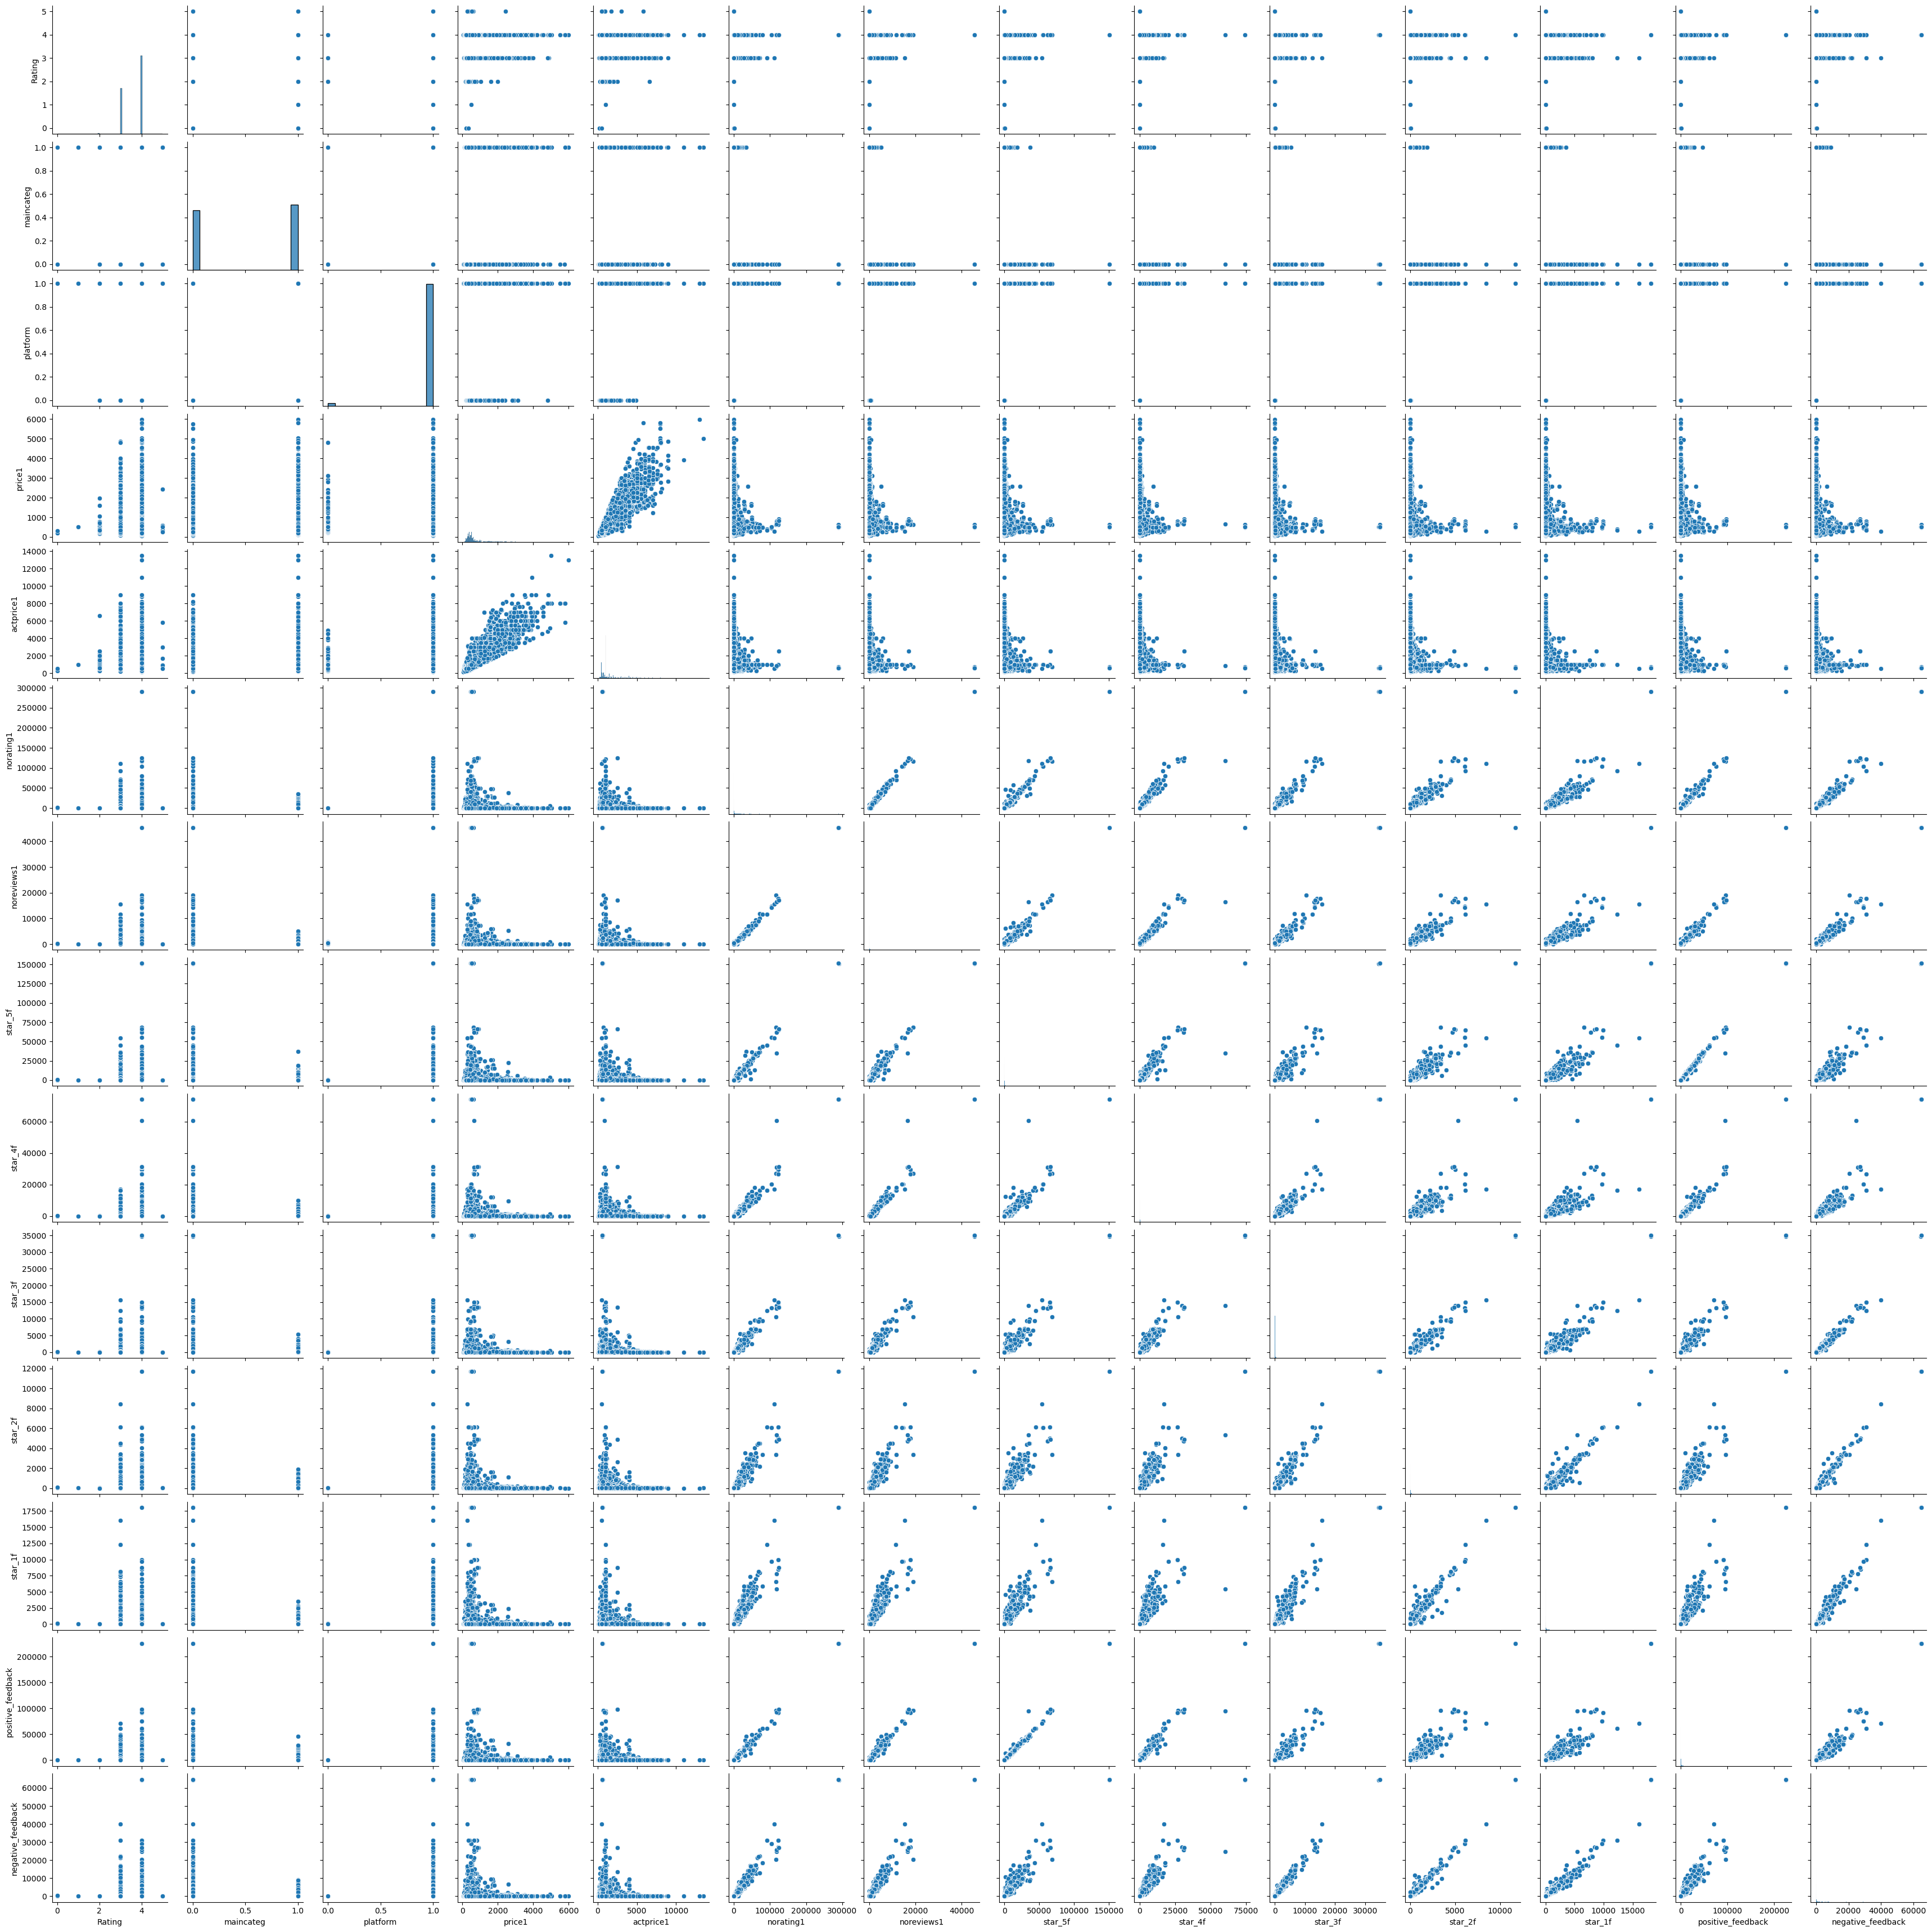

In [74]:
sns.pairplot(df1)

In [75]:
df1.head(3)

,Rating,maincateg,platform,price1,actprice1,norating1,noreviews1,star_5f,star_4f,star_3f,star_2f,star_1f,positive_feedback,negative_feedback
0,3,1,1,698,999,38,7,17,9,6,3,3,26,12
1,3,0,1,999,1999,531,69,264,92,73,29,73,356,175
2,4,1,1,2749,4999,17,4,11,3,2,1,0,14,3


In [76]:
x=df1.drop('price1',axis=1)
y=df1['price1']

In [77]:
x

,Rating,maincateg,platform,actprice1,norating1,noreviews1,star_5f,star_4f,star_3f,star_2f,star_1f,positive_feedback,negative_feedback
0,3,1,1,999,38,7,17,9,6,3,3,26,12
1,3,0,1,1999,531,69,264,92,73,29,73,356,175
2,4,1,1,4999,17,4,11,3,2,1,0,14,3
3,4,0,1,724,46413,6229,1045,12416,5352,701,4595,13461,10648
4,3,0,1,2299,77,3,35,21,7,7,7,56,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15723,4,1,1,499,219,21,122,39,16,15,24,161,55
15725,4,1,1,1199,807,114,485,177,61,41,43,662,145
15726,3,1,1,998,246,34,120,45,37,16,28,165,81
15727,3,1,1,499,202,18,130,37,20,10,15,168,45


In [78]:
y

0         698
1         999
2        2749
3         518
4        1379
         ... 
15723     209
15725     567
15726     499
15727     329
15728    2249
Name: price1, Length: 15089, dtype: int32

In [79]:
from sklearn.model_selection import train_test_split

In [80]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [81]:
x_train.shape

(12071, 13)

In [82]:
x_test.shape

(3018, 13)

In [83]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler(feature_range=(0,1))         # all the values are transfered from 0 to 1
x_train_transformed=scaler.fit_transform(x_train)
x_test_transformed=scaler.transform(x_test)

In [84]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train_transformed,y_train)

LinearRegression()

In [85]:
y_pred=lr.predict(x_test_transformed)
y_pred

array([544.34766294, 275.95392321, 293.98787004, ..., 198.71707024,
       913.23642612, 912.22352925])

In [86]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.7982333280035888

In [87]:
!pip install xgboost

In [88]:
!pip install catboost

In [89]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from xgboost import XGBRegressor,XGBRFRegressor
from sklearn.metrics import mean_squared_error
from catboost import CatBoostRegressor

In [90]:
from sklearn.metrics import r2_score


In [91]:
modeld=DecisionTreeRegressor()
modelr=RandomForestRegressor()
modelxgb = XGBRegressor()
modelxgbrf=XGBRFRegressor()
modelcat=CatBoostRegressor(verbose= False)

In [92]:
def train_and_evaluate(model,X_train,y_train, X_val,y_val,**params):  #**params
    model.fit(X_train, y_train)
    train_rmse =mean_squared_error(model.predict(X_train), y_train,squared=False)
    val_rmse = mean_squared_error(model.predict(X_val), y_val,squared=False)
    r2score= r2_score( y_val,model.predict(X_val))
    return model, train_rmse, val_rmse,r2score

In [93]:
train_and_evaluate(modeld,x_train_transformed,y_train, x_test_transformed,y_test)

(DecisionTreeRegressor(),
 28.49317429816318,
 262.17315000108493,
 0.8298769474464216)

In [94]:
train_and_evaluate(modelr,x_train_transformed,y_train, x_test_transformed,y_test)

(RandomForestRegressor(),
 79.1173999706686,
 203.09981787646396,
 0.8979046857074819)

In [95]:
train_and_evaluate(modelxgb,x_train_transformed,y_train, x_test_transformed,y_test)

(XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
              colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, gamma=0, gpu_id=-1,
              grow_policy='depthwise', importance_type=None,
              interaction_constraints='', learning_rate=0.300000012, max_bin=256,
              max_cat_threshold=64, max_cat_to_onehot=4, max_delta_step=0,
              max_depth=6, max_leaves=0, min_child_weight=1, missing=nan,
              monotone_constraints='()', n_estimators=100, n_jobs=0,
              num_parallel_tree=1, predictor='auto', random_state=0, ...),
 107.46444783639494,
 213.07492352638695,
 0.8876297298447847)

In [96]:
train_and_evaluate(modelxgbrf,x_train_transformed,y_train, x_test_transformed,y_test)

(XGBRFRegressor(base_score=0.5, booster='gbtree', callbacks=None,
                colsample_bylevel=1, colsample_bytree=1,
                early_stopping_rounds=None, enable_categorical=False,
                eval_metric=None, feature_types=None, gamma=0, gpu_id=-1,
                grow_policy='depthwise', importance_type=None,
                interaction_constraints='', max_bin=256, max_cat_threshold=64,
                max_cat_to_onehot=4, max_delta_step=0, max_depth=6, max_leaves=0,
                min_child_weight=1, missing=nan, monotone_constraints='()',
                n_estimators=100, n_jobs=0, num_parallel_tree=100,
                objective='reg:squarederror', predictor='auto', random_state=0,
                reg_alpha=0, ...),
 242.27036303858534,
 261.334730054724,
 0.8309633019460806)

In [97]:
train_and_evaluate(modelcat,x_train_transformed,y_train, x_test_transformed,y_test)

(<catboost.core.CatBoostRegressor at 0x29fcb41e760>,
 154.9569820625344,
 217.14029469060114,
 0.8833008780857959)

In [98]:
ran=RandomForestRegressor(n_estimators=110,max_depth=40,random_state=42)
ran.fit(x_train_transformed,y_train)
ran.score(x_test_transformed,y_test)

0.8960732285278509